In [69]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [70]:
iris = load_iris(as_frame=True)
df = iris.frame
X = df.drop(columns=['target'])
y = df['target']

print("DATASET SHAPE & STRUCTURE")
print(f"Total Rows (Samples): {df.shape[0]}")
print(f"Total Columns (Features + Target): {df.shape[1]}")


DATASET SHAPE & STRUCTURE
Total Rows (Samples): 150
Total Columns (Features + Target): 5


In [71]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [73]:
print(df.describe().T)

                   count      mean       std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.758000  1.765298  1.0  1.6  4.35  5.1  6.9
petal width (cm)   150.0  1.199333  0.762238  0.1  0.3  1.30  1.8  2.5
target             150.0  1.000000  0.819232  0.0  0.0  1.00  2.0  2.0


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [75]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [77]:
y_pred = knn_model.predict(X_test_scaled)

In [78]:
print("\n[Confusion Matrix Table]")
print(confusion_matrix(y_test, y_pred))


[Confusion Matrix Table]
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [79]:
print("\n[Detailed Classification Metrics]")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


[Detailed Classification Metrics]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [80]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

train_scores = []
test_scores = []

for k in range(1, 31):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    train_scores.append(model.score(X_train_scaled, y_train))
    test_scores.append(model.score(X_test_scaled, y_test))

best_k = np.argmax(test_scores) + 1

print("Best k:", best_k)
print("Best Accuracy:", max(test_scores))

Best k: 3
Best Accuracy: 1.0


The Elbow Method

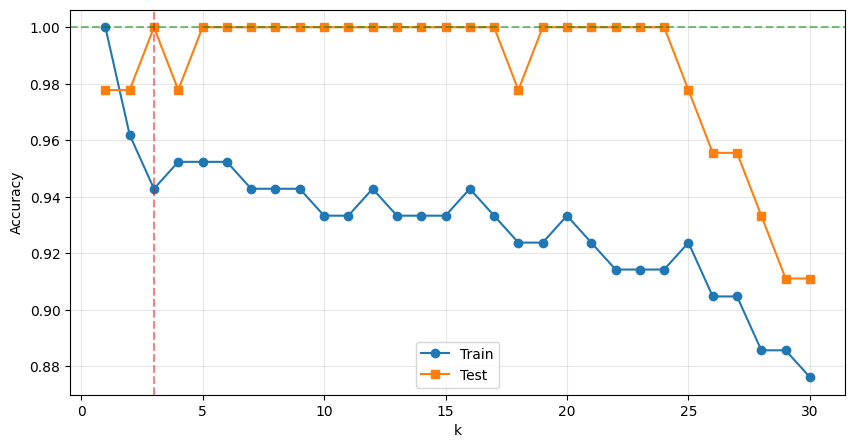

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, 'o-', label='Train')
plt.plot(k_values, test_scores, 's-', label='Test')
plt.xlabel('k'); plt.ylabel('Accuracy')
plt.axvline(best_k, color='r', linestyle='--', alpha=0.5)
plt.axhline(best_score, color='g', linestyle='--', alpha=0.5)
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [82]:
print("Best k:", best_k)
print("Best Accuracy:", max(test_scores))

Best k: 3
Best Accuracy: 1.0
